# **Unemployment Analysis with Python**

**1: Importing the Required Libraries.**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**2: Load the dataset**

In [2]:
df = pd.read_csv('Unemployment in India.csv')

**3. EDA (Exploratory Data Analysis)**

In [3]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [4]:
df.shape

(768, 7)

In [5]:
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

Here, the values of every column of a row is NaN, So they gave no insights, that's why it is better to drop them.

In [6]:
df.dropna(how = 'all', inplace = True)

In [7]:
#striping the space from text column
df['Region'] = df['Region'].str.strip()
df['Area'] = df['Area'].str.strip()

In [8]:
df.columns = df.columns.str.strip()

In [9]:
#converting date to proper date-time format
df['Date'] = pd.to_datetime(df['Date'].str.strip(), format='%d-%m-%Y')

Data set after cleaning

In [10]:
df.shape

(740, 7)

**4: Basic Statistics**

In [11]:
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


**5: CHART 1 — Overall Unemployment Rate Over Time**

**Q1**: Did it spike during COVID lockdown in April 2020?

I used a line chart because the data is time-based (Numerical vs Categorical). Line charts are best to show trends over a period. It clearly shows how unemployment increased or decreased each month, especially during COVID.

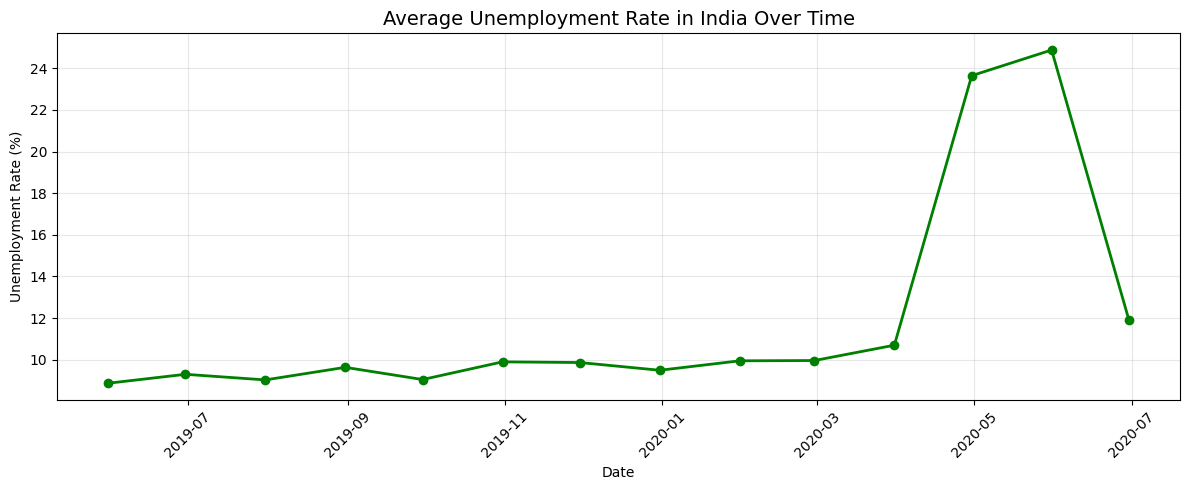

In [12]:
plt.figure(figsize=(12,5))
monthly_avg = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()
plt.plot(monthly_avg.index, monthly_avg.values, color='green', linewidth=2, marker='o')
plt.title('Average Unemployment Rate in India Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('chart1_unemployment_over_time.png')
plt.show()

**6: CHART 2 — Rural vs Urban Unemployment**

I used a line chart to compare two categories over time. It helps us easily see the difference between Rural and Urban unemployment trends and identify which area was more affected.

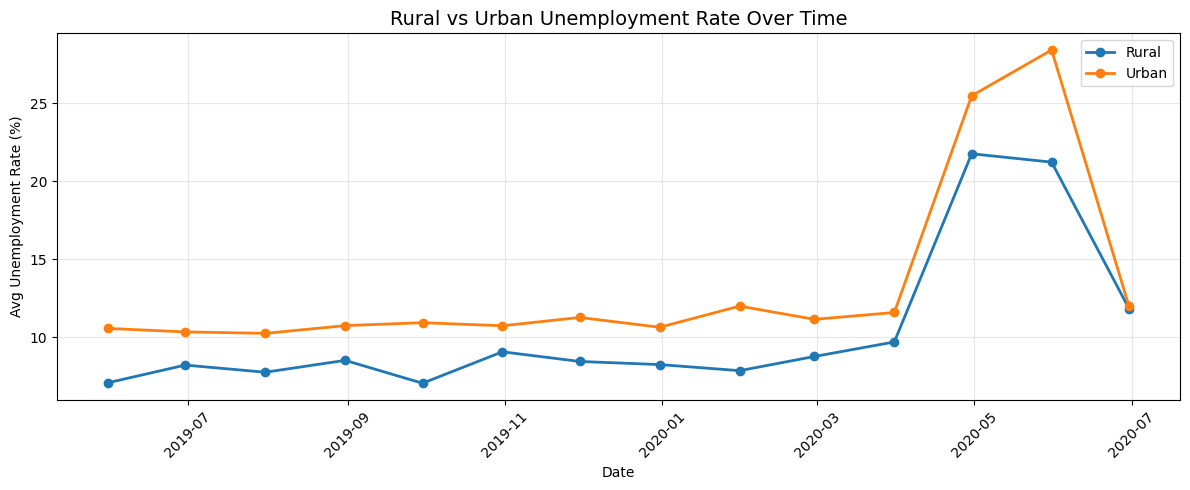

In [13]:
plt.figure(figsize=(12,5))
area_avg = df.groupby(['Date','Area'])['Estimated Unemployment Rate (%)'].mean().reset_index()

for area in ['Rural','Urban']:
  data = area_avg[area_avg['Area'] == area]
  plt.plot(data['Date'], data['Estimated Unemployment Rate (%)'], label=area, linewidth=2, marker='o')

plt.title('Rural vs Urban Unemployment Rate Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Avg Unemployment Rate (%)')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('chart2_rural_vs_urban.png')
plt.show()

**7: CHART 3 — Top 10 States with Highest Avg Unemployment**

I used a bar chart because we are comparing different states. Bar charts are best for comparing categories and clearly showing which states have higher unemployment rates.

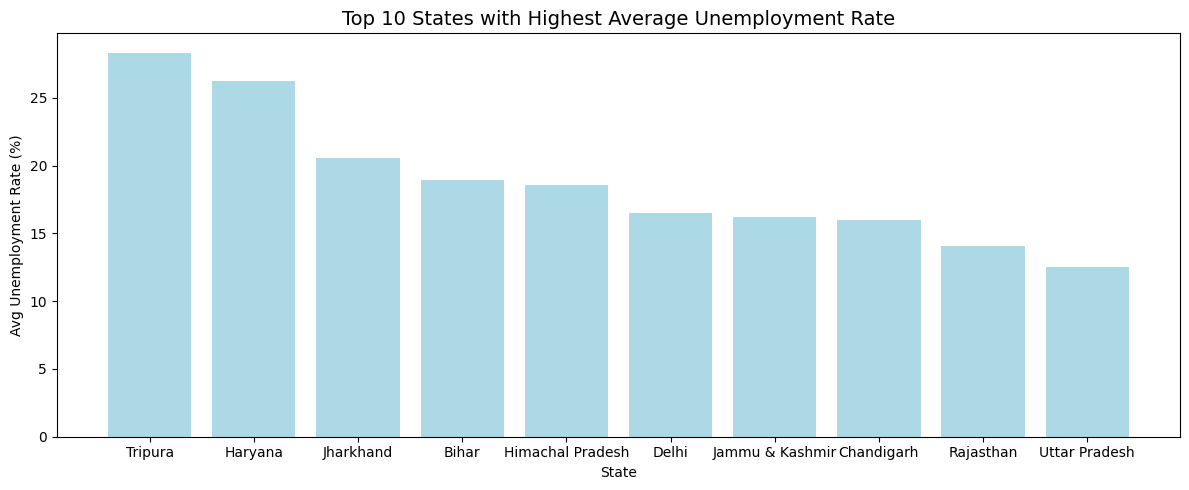

In [14]:
plt.figure(figsize=(12,5))
state_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).head(10)
plt.bar(state_avg.index, state_avg.values, color='lightblue')
plt.title('Top 10 States with Highest Average Unemployment Rate', fontsize = 14)
plt.ylabel('Avg Unemployment Rate (%)')
plt.xlabel('State')
plt.tight_layout()
plt.savefig('chart3_top10_states.png')
plt.show()

**8: CHART 4 — Heatmap (State-wise unemployment by month)**

I used a heatmap to show large data in a compact form. It helps quickly identify high and low unemployment months across states using color intensity.

cmap='YlOrRd' -> Yellow to Red color scale

Light color = low

Dark red = high unemployment

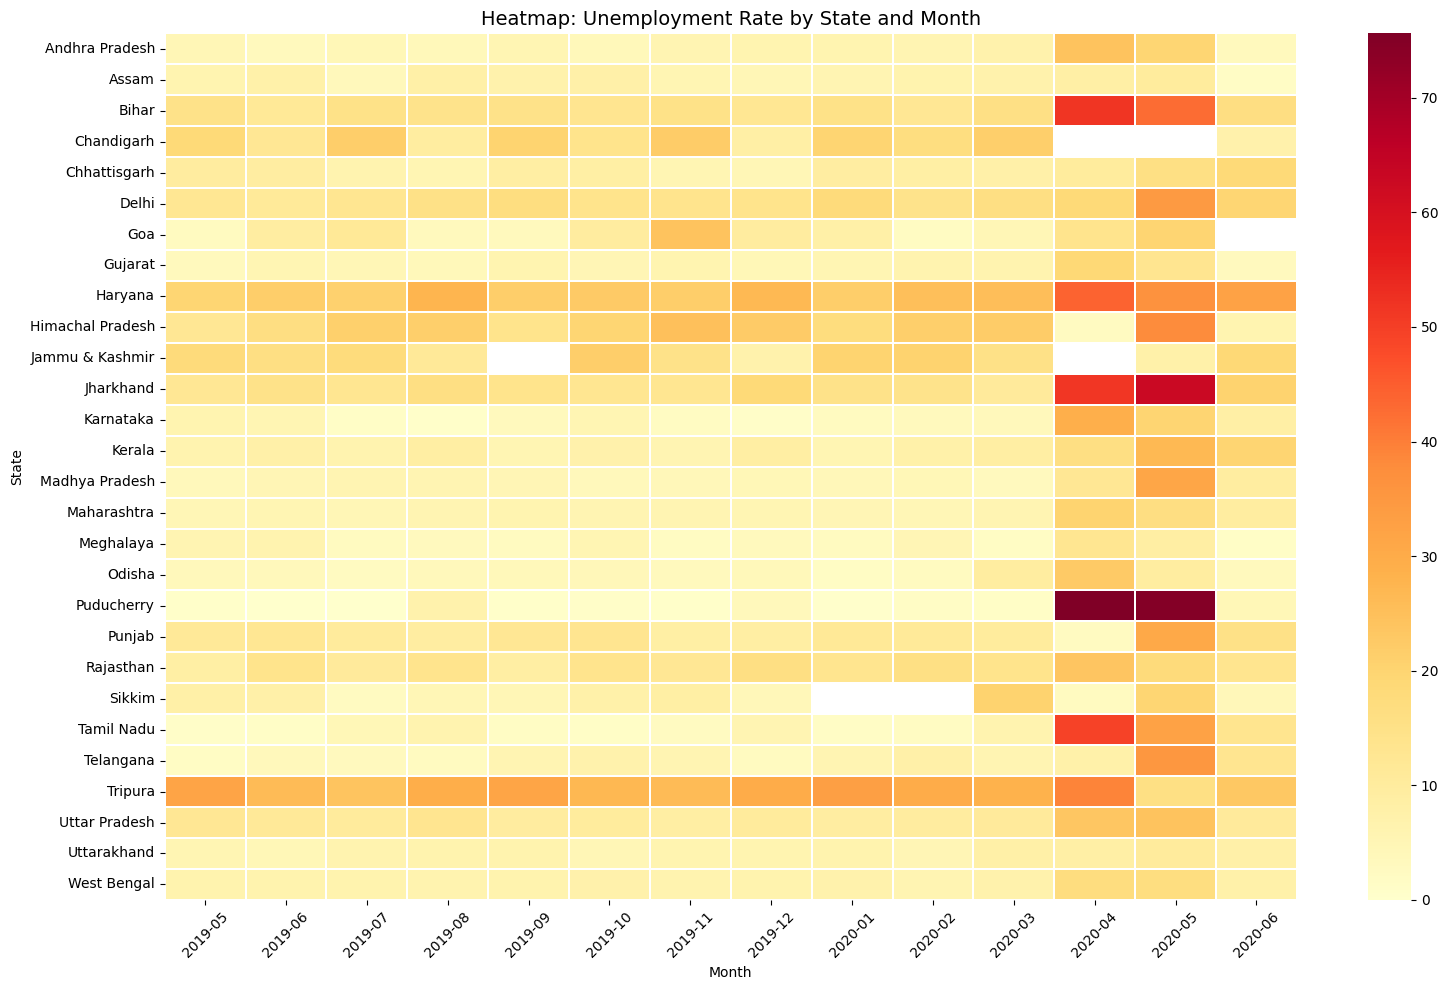

In [15]:
plt.figure(figsize=(16,10))

df['Month'] = df['Date'].dt.to_period('M').astype(str)

pivot = df.pivot_table(
    values='Estimated Unemployment Rate (%)',
    index='Region',
    columns='Month',
    aggfunc='mean'
)

sns.heatmap(pivot, cmap="YlOrRd", linewidths=0.3, annot=False)

plt.title('Heatmap: Unemployment Rate by State and Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('State')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart4_heatmap.png')
plt.show()

So, from the above graph we can say that the in the month of April_2020 and May_2020 maximum people in Puducherry State were Unemployed.


# **Conclusion**

In this project, I analyzed unemployment trends in India using Python. I observed how unemployment changed over time, especially during COVID-19, and compared Rural and Urban areas. Using different charts helped me clearly understand state-wise and monthly patterns. This project improved my skills in data cleaning, analysis, and visualization.